# 日経平均株価 週足 メディアン統計とモメンタム

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import yfinance as yf
from scipy import stats

from funcs.technical import calc_robust_bollinger

In [3]:
code = "N225"
symbol = "^%s" % code
yticker = yf.Ticker(symbol)

In [4]:
### 最新のデータが取得されていることを確認 ###
yticker.history(period="5d", interval="1d")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-03 00:00:00+09:00,63834.949219,63905.121094,62703.468750,63754.898438,202700000,0.0,0.0
2026-08-04 00:00:00+09:00,63995.281250,64240.500000,62864.429688,63957.531250,191800000,0.0,0.0
2026-08-05 00:00:00+09:00,64565.269531,66302.523438,64555.519531,66300.437500,202400000,0.0,0.0
2026-08-06 00:00:00+09:00,65896.000000,65983.132812,64942.070312,65683.257812,191500000,0.0,0.0
2026-08-07 00:00:00+09:00,65746.132812,65990.718750,64651.488281,65606.710938,205400000,0.0,0.0


In [5]:
# 週足で過去 5 年分のデータを取得
df0 = yticker.history(period="10y", interval="1wk")

# ローソク足のチャートには、そのうち過去 3 年分のみ使用する
dt_last = df0.index[len(df0) - 1]
tdelta_2y = datetime.timedelta(days=365 * 2)
df = df0[df0.index >= dt_last - tdelta_2y]

In [6]:
dt = df.tail(1).index[0]
year_str = f"{dt.year:04d}"
date_str = f"{dt.month:02d}{dt.day:02d}"
date_str

'0803'

## Moving Median

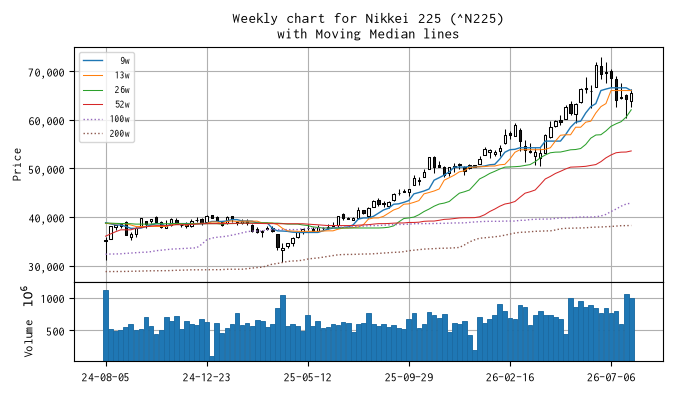

In [7]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

fig = plt.figure(figsize=(6.8, 4))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[3 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

mm09 = df0["Close"].rolling(9).median()
mm13 = df0["Close"].rolling(13).median()
mm26 = df0["Close"].rolling(26).median()
mm52 = df0["Close"].rolling(52).median()
mm100 = df0["Close"].rolling(100).median()
mm200 = df0["Close"].rolling(200).median()

apds = [
    mpf.make_addplot(mm09[df.index], width=1, label="  9w", ax=ax[0]),
    mpf.make_addplot(mm13[df.index], width=0.75, label=" 13w", ax=ax[0]),
    mpf.make_addplot(mm26[df.index], width=0.75, label=" 26w", ax=ax[0]),
    mpf.make_addplot(mm52[df.index], width=0.75, label=" 52w", ax=ax[0]),
    mpf.make_addplot(
        mm100[df.index],
        width=1,
        linestyle="dotted",
        label="100w",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mm200[df.index],
        width=1,
        linestyle="dotted",
        label="200w",
        ax=ax[0],
    ),
]

mpf.plot(
    df,
    type="candle",
    style="default",
    volume=ax[1],
    datetime_format="%y-%m-%d",
    addplot=apds,
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax[0],
)

ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[0].set_title(
    f"Weekly chart for {yticker.info["longName"]} ({symbol})\nwith Moving Median lines"
)
ax[0].legend(loc="upper left", fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(year_str, f"{date_str}_report_weekly_chart_median_{code}.png"))
plt.show()

In [8]:
df.tail(2)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-07-27 00:00:00+09:00,65164.980469,65364.730469,60448.898438,64362.019531,1054000000,0.0,0.0
2026-08-03 00:00:00+09:00,63834.949219,66302.523438,62703.468750,65606.710938,993800000,0.0,0.0


In [9]:
df.tail(2)["Close"]

Date
2026-07-27 00:00:00+09:00    64362.019531
2026-08-03 00:00:00+09:00    65606.710938
Name: Close, dtype: float64

In [10]:
df.tail(2)["Close"].diff()

Date
2026-07-27 00:00:00+09:00            NaN
2026-08-03 00:00:00+09:00    1244.691406
Name: Close, dtype: float64

In [11]:
df["Close"].rolling(9).median().tail(10)

Date
2026-06-01 00:00:00+09:00    61409.289062
2026-06-08 00:00:00+09:00    62713.648438
2026-06-15 00:00:00+09:00    63339.070312
2026-06-22 00:00:00+09:00    66020.039062
2026-06-29 00:00:00+09:00    66329.500000
2026-07-06 00:00:00+09:00    66588.117188
2026-07-13 00:00:00+09:00    66588.117188
2026-07-20 00:00:00+09:00    66588.117188
2026-07-27 00:00:00+09:00    66588.117188
2026-08-03 00:00:00+09:00    66020.039062
Name: Close, dtype: float64

In [12]:
df["Close"].rolling(13).median().tail(10)

Date
2026-06-01 00:00:00+09:00    59513.121094
2026-06-08 00:00:00+09:00    59716.179688
2026-06-15 00:00:00+09:00    61409.289062
2026-06-22 00:00:00+09:00    62713.648438
2026-06-29 00:00:00+09:00    63339.070312
2026-07-06 00:00:00+09:00    66020.039062
2026-07-13 00:00:00+09:00    66020.039062
2026-07-20 00:00:00+09:00    66020.039062
2026-07-27 00:00:00+09:00    66020.039062
2026-08-03 00:00:00+09:00    66020.039062
Name: Close, dtype: float64

In [13]:
df["Close"].rolling(26).median().tail(5)

Date
2026-07-06 00:00:00+09:00    58663.083984
2026-07-13 00:00:00+09:00    59181.695312
2026-07-20 00:00:00+09:00    59614.650391
2026-07-27 00:00:00+09:00    60562.734375
2026-08-03 00:00:00+09:00    62061.468750
Name: Close, dtype: float64

In [14]:
df["Close"].rolling(52).median().tail(5)

Date
2026-07-06 00:00:00+09:00    52767.414062
2026-07-13 00:00:00+09:00    53223.169922
2026-07-20 00:00:00+09:00    53347.691406
2026-07-27 00:00:00+09:00    53372.800781
2026-08-03 00:00:00+09:00    53596.339844
Name: Close, dtype: float64

In [15]:
df0["Close"].rolling(100).median().tail(5)

Date
2026-07-06 00:00:00+09:00    41127.916016
2026-07-13 00:00:00+09:00    41638.355469
2026-07-20 00:00:00+09:00    42226.884766
2026-07-27 00:00:00+09:00    42675.878906
2026-08-03 00:00:00+09:00    42868.609375
Name: Close, dtype: float64

In [16]:
df0["Close"].rolling(200).median().tail(5)

Date
2026-07-06 00:00:00+09:00    38058.171875
2026-07-13 00:00:00+09:00    38135.351562
2026-07-20 00:00:00+09:00    38218.570312
2026-07-27 00:00:00+09:00    38232.589844
2026-08-03 00:00:00+09:00    38259.960938
Name: Close, dtype: float64

## Robust Bollinger bands

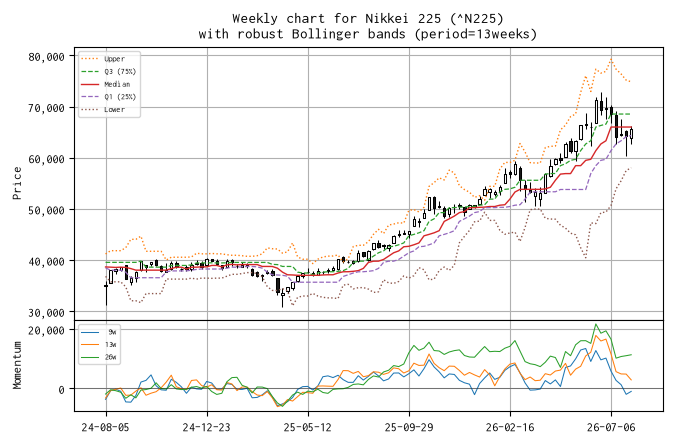

In [17]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

# fig, ax = plt.subplots(figsize=(6, 3.5))
fig = plt.figure(figsize=(6.8, 4.5))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[3 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

# Bollinger bands
period = 13
mv_median = df0["Close"].rolling(period).median()
mv_q1 = df0["Close"].rolling(period).quantile(0.25)
mv_q3 = df0["Close"].rolling(period).quantile(0.75)
mv_iqr = mv_q3 - mv_q1
mv_lower = mv_q1 - mv_iqr * 1.5
mv_upper = mv_q3 + mv_iqr * 1.5

mom09 = df0["Close"] - df0["Close"].shift(9, axis=0)
mom13 = df0["Close"] - df0["Close"].shift(13, axis=0)
mom26 = df0["Close"] - df0["Close"].shift(26, axis=0)

apds = [
    mpf.make_addplot(
        mv_upper[df.index],
        width=1,
        color="C1",
        linestyle="dotted",
        label="Upper",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_q3[df.index],
        width=0.9,
        color="C2",
        linestyle="dashed",
        label="Q3 (75%)",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_median[df.index],
        width=1,
        color="C3",
        linestyle="solid",
        label="Median",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_q1[df.index],
        width=0.9,
        color="C4",
        linestyle="dashed",
        label="Q1 (25%)",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_lower[df.index],
        width=1,
        color="C5",
        linestyle="dotted",
        label="Lower",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mom09[df.index],
        width=0.75,
        linestyle="solid",
        label=" 9w",
        ax=ax[1],
    ),
    mpf.make_addplot(
        mom13[df.index],
        width=0.75,
        linestyle="solid",
        label="13w",
        ax=ax[1],
    ),
    mpf.make_addplot(
        mom26[df.index],
        width=0.75,
        linestyle="solid",
        label="26w",
        ax=ax[1],
    ),
]

mpf.plot(
    df,
    type="candle",
    style="default",
    addplot=apds,
    datetime_format="%y-%m-%d",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax[0],
)

# ax.grid()
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[0].legend(loc="best", fontsize=6)

ax[1].axhline(y=0, color="black", alpha=0.5, linewidth=0.5)
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[1].set_ylabel("Momentum")
ax[1].legend(loc="best", fontsize=6)

try:
    ax[0].set_title(
        f"Weekly chart for {yticker.info['longName']} ({symbol})\nwith robust Bollinger bands (period={period}weeks)"
    )
except KeyError:
    ax[0].set_title(
        f"Weekly chart for {symbol}\nwith robust Bollinger bands (period={period}weeks)"
    )

plt.tight_layout()
plt.savefig(
    os.path.join(
        year_str, f"{date_str}_report_weekly_chart_bollinger_robust_{code}.png"
    )
)
plt.show()

## ヒストグラムと Q-Q プロット

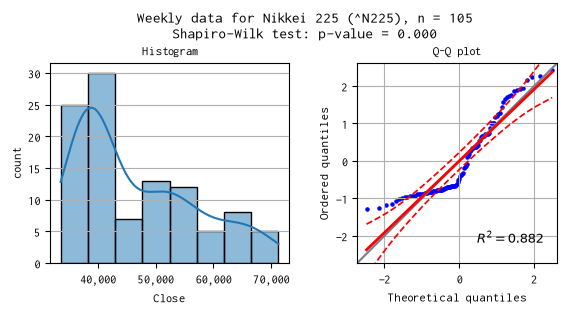

In [18]:
plt.rcParams["font.size"] = 9
fig, axes = plt.subplots(1, 2, figsize=(6.8, 3))

sns.histplot(df["Close"], kde=True, ax=axes[0])

# ヒストグラム
axes[0].set_xlabel("Close")
axes[0].set_ylabel("count")
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
axes[0].grid(axis="y")
axes[0].set_title("Histogram", fontsize=9)

# Q-Q プロット
pg.qqplot(df["Close"], s=5, ax=axes[1])
axes[1].set_title("Q-Q plot", fontsize=9)
axes[1].grid()

shapiro_test = stats.shapiro(df["Close"])
title_str = (
    f"Weekly data for {yticker.info["longName"]} ({symbol}), n = {len(df)}\n"
    f"Shapiro-Wilk test: p-value = {shapiro_test.pvalue:.3f}"
)
plt.suptitle(
    title_str,
    fontsize=11,
)
plt.subplots_adjust(top=0.80, bottom=0.135, wspace=0.2)
plt.savefig(
    os.path.join(year_str, f"{date_str}_report_weekly_histogram_qqplot_{code}.png")
)
plt.show()